# 01 - EDA: Credit Card Fraud Dataset

Quick look at the raw data before any preprocessing. Goal here is just to understand what we're working with: shape, columns, class balance, missing values, and the shape of the `Amount` distribution.

Dataset: Kaggle Credit Card Fraud Detection - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
The CSV has been downloaded manually and placed at `src/data/creditcard.csv`.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings - just to make wide dataframes easier to read in the notebook.
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## Load data

In [24]:
DATA_PATH = "../data/creditcard.csv"

df = pd.read_csv(DATA_PATH)
df.shape

(284807, 31)

## Basic info 

Shape, first few rows, dtypes.

In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 284807, Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

## Class balance

This dataset is known to be heavily imbalanced (fraud is a small fraction of transactions). Confirming that here - this drives a lot of the modeling decisions later (stratified splits, class weighting, PR-AUC instead of ROC-AUC, etc.).

In [6]:
# Target column is 'Class', which is 0 for non-fraudulent transactions and 1 for fraudulent transactions.
TARGET_COL = "Class"

class_counts = df[TARGET_COL].value_counts().sort_index()
class_pct = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print()
print("Class percentage:")
print(class_pct.round(4))

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


## Missing values

Checking for any nulls before getting further into this.

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found.")
else:
    print("Missing values by column:")
    print(missing)

No missing values found.


## Basic statistics

Standard `describe()` on the numeric columns

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Plot: class counts (bar chart)

Logging scale on the y-axis, otherwise the fraud bar is basically invisible next to the non-fraud bar.

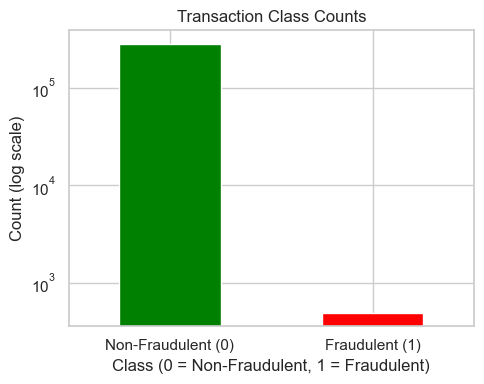

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["green", "red"])
ax.set_title("Transaction Class Counts")
ax.set_xlabel("Class (0 = Non-Fraudulent, 1 = Fraudulent)")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.set_xticklabels(["Non-Fraudulent (0)", "Fraudulent (1)"], rotation=0)
plt.tight_layout()
plt.show()

## Plot: transaction amount distribution

First the overall distribution, then split by class. Amounts are usually right-skewed (lots of small transactions, a long tail of large ones), so also looking at a log-transformed version.

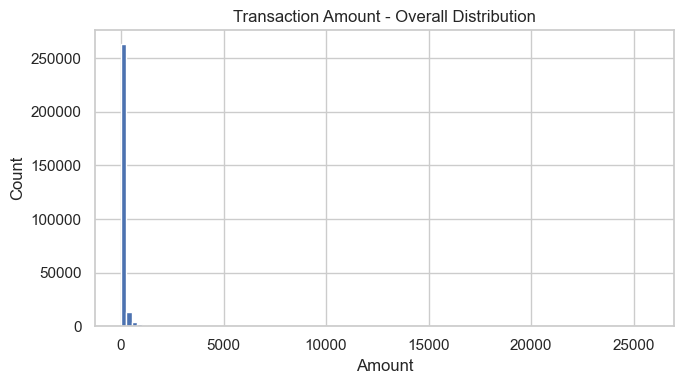

In [21]:
# Amount column is named "Amount".
AMOUNT_COL = "Amount"

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df[AMOUNT_COL], bins=100)
ax.set_title("Transaction Amount - Overall Distribution")
ax.set_xlabel("Amount")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

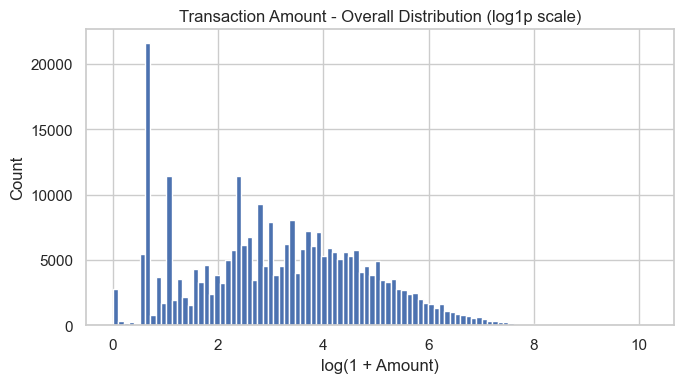

In [22]:
# Same thing but log-scaled on the x-axis to see the distribution of smaller amounts more clearly.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log1p(df[AMOUNT_COL]), bins=100)
ax.set_title("Transaction Amount - Overall Distribution (log1p scale)")
ax.set_xlabel("log(1 + Amount)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

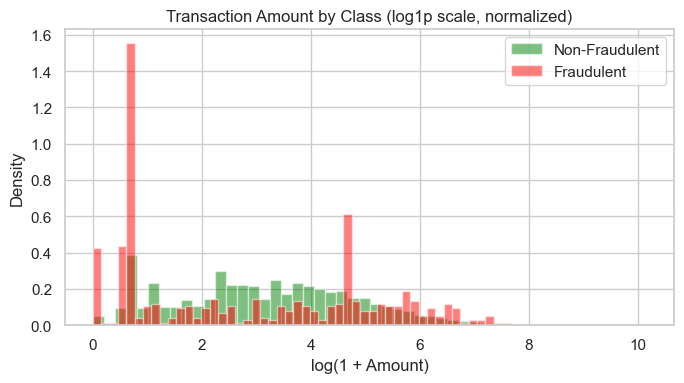

In [23]:
# Split by class - overlaid histograms, normalized so the shapes are comparable despite the huge class imbalance.
fig, ax = plt.subplots(figsize=(7, 4))
for cls, label, color in [(0, "Non-Fraudulent", "green"), (1, "Fraudulent", "red")]:
    subset = df.loc[df[TARGET_COL] == cls, AMOUNT_COL]
    ax.hist(np.log1p(subset), bins=50, alpha=0.5, density=True, label=label, color=color)

ax.set_title("Transaction Amount by Class (log1p scale, normalized)")
ax.set_xlabel("log(1 + Amount)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()